<a href="https://colab.research.google.com/github/Team-Brevity/engineering-methods/blob/main/Plasterboard_NZBC_New_Zealand_Engineering_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Engineering Method - NZBC, Seismic Restraint of Plasterboard Ceilings



Created by *Nima Shokrollahi* on *11 November 2024*

Approved by *Name of CPEng approver, CPEng #XXXXXX*, on behalf of Brevity Ltd

Copyright (c) Brevity Ltd 2025

**Version summary:**

16 January 2025 - v 0.1 - Concept

In [ ]:
# Standard Python Libraries
import numpy as np
import pandas as pd

In [ ]:
# SI units
m = 1
N = 1
sec = 1
kg = 1
Pa = 1

# Constants
PI = 2 * np.arcsin(1.0)  # pi
g = 9.806 * m / pow(sec, 2)  # acceleration due to gravity
Ubig = 1.0e10  # a really large number
Usmall = 1 / Ubig  # a really small number

#input units - convert non-SI to SI on variable initialisation
# e.g. input length in mm -> length = 1000 * mm will output m
cm = m / 100  # centimeter
mm = m / 1000  # milimeter
inch = 2.54 * cm
foot = 12 * inch
kN = N * (1.0e3)
kPa = Pa * (1.0e3)
MPa = Pa * (1.0e6)

#conversions
# use / , eg. convert 1000 Pa to kPa
# pressure = 1000 * Pa
# pressure_kPa = pressure / kPa

# Reference Documents

The following documents have been referenced in the development of this method. They should be considered essential background readings before reading, reviewing or using this method:

# Compliance Pathway - Deemed to satisfy NCC B1 Structural provisions

1. B1D1 - B1D6 represent the compliance pathway under NCC B1 for deemed to satisfy solutions.

2. In regards to B1D3, the relevant individual actions for **Plasterboard ceilings** are self weight and imposed loads, earthquake actions, and wind actions. The grid is the primary structural system, and is constructed of connected extruded aluminium sections. Therefore, this method calculates actions and capacity to the following standards.:

> AS/NZS 1170.0:2002, A1-5 - Structural design actions, General principals
>
> AS/NZS 1170.2:2021, A1 - Structural design actions, Wind actions
>
> AS 1170.4:2007 - Structural design actions, Earthquake actions
>
> AS/NZS 4600:2018 - Cold formed steel

In [ ]:
# Import design and materials standards from Constratum library, follow link to
#review standards
%pip install git+https://github.com/Constratum/engineering-standards.git


  Cloning https://github.com/Constratum/engineering-standards.git to /tmp/pip-req-build-l6wwsv3c
  Running command git clone --filter=blob:none --quiet https://github.com/Constratum/engineering-standards.git /tmp/pip-req-build-l6wwsv3c
  Resolved https://github.com/Constratum/engineering-standards.git to commit 3e5cbba0dcdb69a7a82849ec1e9fd85847a3d5fa
  Preparing metadata (setup.py) ... done
  Created wheel for engineering_standards: filename=engineering_standards-0.21-py3-none-any.whl size=192353 sha256=6df5be9aad086726eb044bf80c326c82c8305444ee2258e565b1326e709073e9
  Stored in directory: /tmp/pip-ephem-wheel-cache-uw1u3tp8/wheels/e9/d1/56/473ec289b17d2efec0a3690393ed9b3cff9c2cf6a515f19ca7
Successfully built engineering_standards


In [ ]:
#Design standards imports
from nz_standards import NZS_1170_5_2004
from nz_standards import AS_NZS_1170_0_2002
from nz_standards import AS_NZS_1170_2_2021_A2

Spectral shape factor = 1.33
Hazard factor = 0.13
Major fault distance = 20
Return period factor = 1.0
Near fault factor = 1.0
Elastic site spectra = 0.17290000000000003
Sp_stability = 1.0, Sp_ULS = 0.925, Sp_SLS = 0.7
0.13994093750000003
Part risk factor = 1.0
Part limit state = Earthquake ULS
Floor height coefficient = 3.0
Part spectral shape factor = 2.0
Part design response coefficient = 1.0374
Part response factor = 1.0
Part horizontal design action = 10.374 N
Load factor for selected action is: 1.5


# Free Body Diagram


# Project Specifications

In [ ]:
# Project Inputs report New Zealand
#@title { run: "auto", vertical-output: true }
#@markdown Project location:
location = "Auckland" #@param ['Akaroa','Alexandra','Arrowtown','Arthurs Pass','Ashburton','Auckland','Balclutha','Blenheim','Bluff','Bulls','Cambridge','Cheviot','Christchurch','Cromwell ','Dannevirke','Darfield','Dargarville','Dunedin','Eastbourne - Point Howard','Fairlie','Fielding','Fox Glacier','Foxton/Foxton Beach','Franz Josef','Geraldine','Gisborne','Gore','Greymouth','Hamilton','Hanmer Springs','Harihari','Hastings','Hawera','Hokitika','Huntly','Hutt Valley - south of Taita Gorge','Ingelwood','Invercargill','Kaikohe','Kaikoura','Kaitaia','Kawerau','Levin','Manakau City','Mangakino','Marton','Masterton','Matamata','Mataura','Milford Sound','Morrinsville','Mosgiel','Motueka','Mount Maunganui','Mt Cook','Murchison','Murupara','Napier','Nelson','New Plymouth','Ngaruawahia','Oamaru','Oban','Ohakune','Opotiki','Opunake','Otaki','Otira','Otorohanga','Paeroa','Pahiatua','Paihia/Russell','Palmerston ','Palmerston North','Paraparaumu','Patea','Picton','Porirua','Pukekohe','Putaruru','Queenstown','Raetihi','Rangiora','Reefton','Riverton','Rotorua','Ruatoria','Seddon','Springs Junction','St Arnaud','Stratford','Taihape','Takaka ','Taumaranui','Taupo','Tauranga','Te Anua','Te Aroha','Te Awamutu','Te Kuiti','Te Puke','Temuka','Thames','Timaru','Tokoroa','Turangi','Twizel','Upper Hutt','Waihi','Waikanae','Waimate','Wainiuomata','Waiouru','Waipawa','Waipukurau','Wairoa','Waitara','Waiuku','Wanaka','Wanganui','Ward','Warkworth','Wellington ','Wellington CBD (north of Basin Reserve)','Westport','Whakatane','Whangerei','Winton','Woodville']
#? If the location of your project is not shown, pick the closest town or city.

#@markdown Importance Level:
importance_level = 3 #@param ["1", "2", "3", "4"] {type:"raw"}
#? This is the project Importance Level, as defined in AS/NZS 1170.0.

#@markdown Site subsoil type:
subsoil_type = "C Shallow soil" #@param ["A Strong rock and B rock", "C Shallow soil", "D Deep or very soft soil", "E Very soft soil"]
#? This is a specialist Geotechnical definition. If you are unsure of the site subsoil type, D is usually a conservative choice.

#@markdown Design working Life:
design_working_life = "50 years" #@param ["Construction equipment", "Less than 6 months", "5 years", "25 years", "50 years", "100 years or more"]
#?  This is the design working life for the building, as defined in AS/NZS 1170.0. 50 years is the standard design working life in the NZ building code.

#@markdown Total height of the building above ground (m):
building_height =  100 #@param {type:"number"}
#?This is the height in meters from ground level to the top of the building.

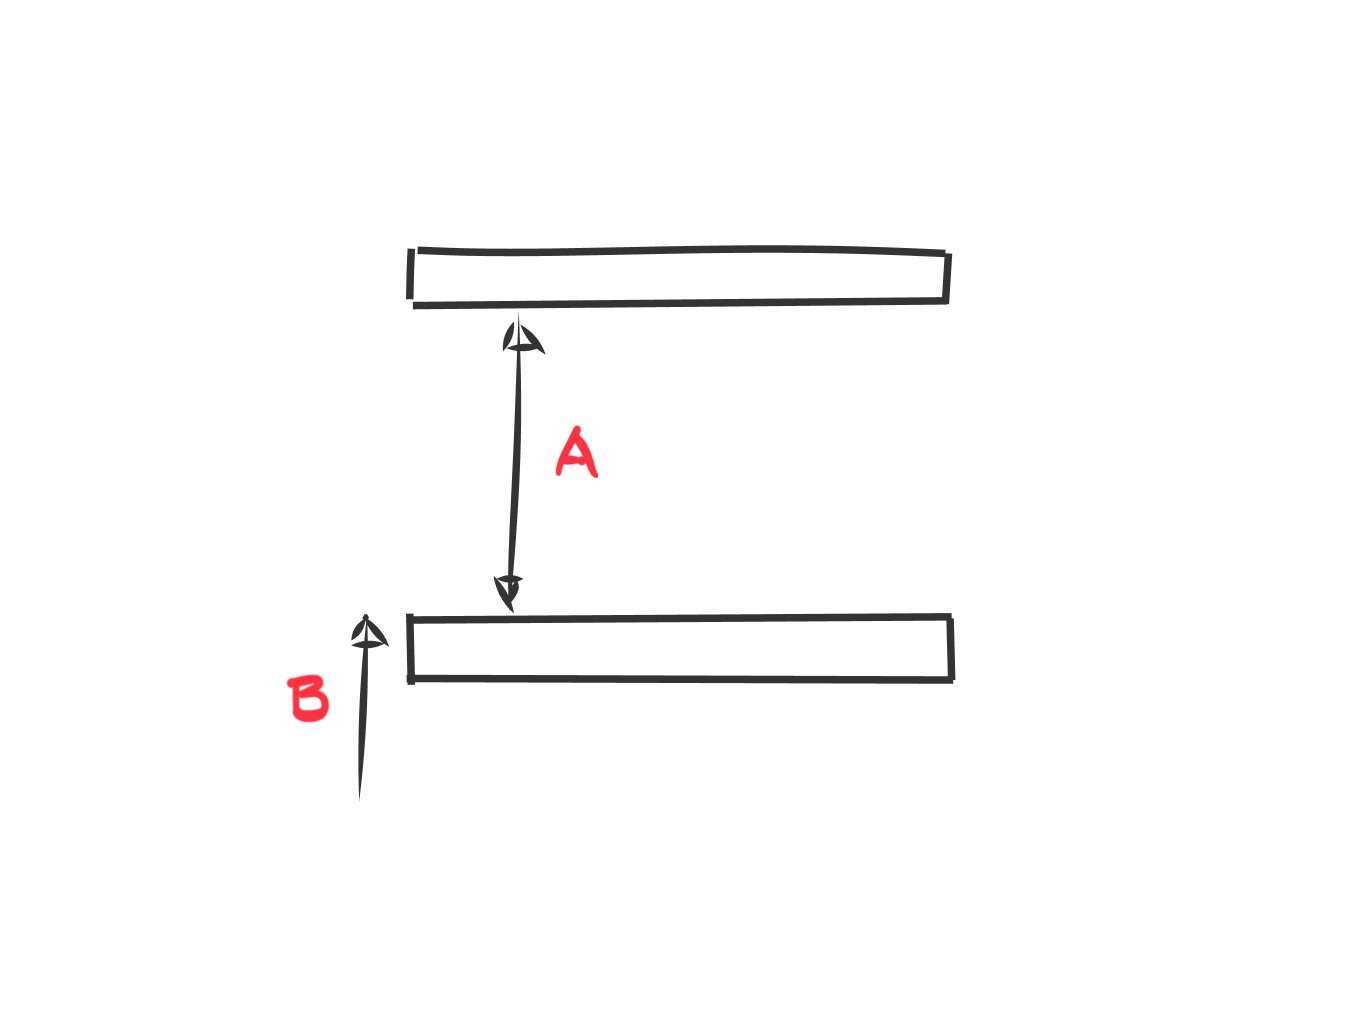

In [ ]:
# Level Inputs report

#@markdown (A) Floor structure height (m):
floor_height = 4 #@param {type:"number"}
#? This is the height from floor level to the structure above.


#@markdown (B) Level height (m):
level_height =  1 #@param {type:"number"}
#? This is the height of the floor above the ground.

In [ ]:
# Model Inputs for notebook report

#@markdown plasterboard braced subtype:
braced_subtype = True #@param {"type":"boolean"}

# @markdown Maximum ceiling dimension in top cross rail direction (mm)
top_cross_rail_length = 10000 # @param {type:"number"}

# @markdown Maximum ceiling dimension in furring channel direction (mm)
furring_channel_length = 10000 # @param {type:"number"}

# @markdown Rake angle in degrees
rake_angle = 0 # @param {type:"number"}

#@markdown Ceiling height (m):
ceiling_height = 2.7 #@param {type:"number"} #m
#? This is the height of the ceiling from the floor level.

#@markdown top cross rail spacing (mm):
top_cross_rail_spacing = 1200 #@param ["600", "1200", "1350","1500"] {type:"raw"}
#? This is the spacing between top cross rails.

#@markdown top cross rail spacing (mm):
furring_channel_spacing = 1200 #@param ["400","450", "600", "1200","1350","1500"] {type:"raw"}
#? This is the spacing between top cross rails.


#@markdown Hanger spacing (mm):
hanger_spacing = 1200 #@param ["1000","1100","1200"] {type:"raw"}
#? This is the spacing between top cross rail hangers.


In [ ]:
ceiling_aspect_ratio = top_cross_rail_length / furring_channel_length

In [ ]:
# Define Pre Define Actions
#@markdown Top Cross Rail mass per linear meter (kg/m):
top_cross_rail_mass = 0.363 #@param {type:"number"}

#@markdown Furring Channel mass per linear meter (kg/m):
furring_channel_mass = 0.363 #@param {type:"number"}

#@markdown Lining mass (kg/sqm):
lining_mass = 1.5 #@param {type:"number"}

#@markdown Additional mass per square meter (kg/sqm):
manual_mass = 0 #@param {type:"number"}

In [ ]:
#@markdown consider ULS wind loads on building element
wind = False # @param {"type":"boolean","placeholder":"false"}

#@markdown define terrain category
terrain_category = "TC2" #@param ["TC1", "TC2", "TC3", "TC4"]

#@markdown internal_condition
internal_condition = "sealed" #@param ["adjacent", "sealed", "unsealed"]


# Design Actions on Part

## Seismic Actions

### Mass of ceiling grid (G) and imposed load (Q)

In [ ]:
# Define notebook - report Pre Calculation

# calculate grid mass per sqm for all grid types
grid_mass_calculations = (( top_cross_rail_mass / (top_cross_rail_spacing * mm) ) + (furring_channel_mass / (furring_channel_spacing * mm)))

# set grid mass based on grid type selected
grid_mass = grid_mass_calculations * kg / m **2

ceiling_area = (top_cross_rail_length * mm) * (furring_channel_length * mm) * m **2

# Calculate total mass
Gc = ((( grid_mass + lining_mass + manual_mass ) * ceiling_area ) * g ) * N


# convert incidental action to mass, Q
# from AS/NZS 2785 clause 2.2.2 (c), incidental action is 0.03 kPa.
incidental_action = (0.03 * kPa) * Pa

#calculate incidental mass in kg/sqm
Q = ( incidental_action * ceiling_area ) * N

In [ ]:
a = 2 +2
a

4

### Seismic design action (N)

In [ ]:
# Project Assumptions for seismic action calculation
part_category = "P2/P3"

Rp, pLS = NZS_1170_5_2004.part_risk_factor_limit_state(part_category)

# calculate h_i in m from level height and ceiling height

h_i = level_height + ceiling_height

C_Hi = NZS_1170_5_2004.floor_height__coefficient(h_i, building_height)

# Set part period to 0 seconds (assumption valid for comparatively stiff parts)
Tp = 0

CiTp = NZS_1170_5_2004.part_spectral_shape_factor(Tp)

# Set part ductility = 1.25 from AS/NZS4600
part_ductility = 1.25
Cph = NZS_1170_5_2004.part_response_factor(part_ductility)

# from NZS 1170.5 amd AS/NZS 1170.0, determine structure seismic parameters for the part
Z, D = NZS_1170_5_2004.hazard_factor(location)

# Set structure limit state to the limit state from NZS 1170.5 table 8.1
LS = pLS

P = AS_NZS_1170_0_2002.annual_probability_of_exceedence_nzl(
    design_working_life, importance_level, LS
)
R = NZS_1170_5_2004.return_period_factor(P)
# Set structure period to 0 seconds (assumption for part calculations, section 8 NZS1170.5)
T = 0

N_TD = NZS_1170_5_2004.near_fault_factor(P, D, T)

# calculate part responses
CpTp = NZS_1170_5_2004.part_design_response_coefficient(
    subsoil_type, Z, R, N_TD, C_Hi, CiTp
)
#From AS/NZS 2785, Psi_c = Psi_e = 0

Psi_c = 0

seismic_part_weight =  NZS_1170_5_2004.seismic_weight_6_2_6(Gc,Psi_c,Q) * N

Fph = NZS_1170_5_2004.part_horizontal_design_action(
    CpTp,
    Cph,
    Rp,
    seismic_part_weight,
    part_category,
    R
)
Fph = Fph + seismic_part_weight * np.sin(np.deg2rad(rake_angle))
response_coefficient = CpTp

## Wind Actions

### Internal Wind Action

In [ ]:
# Project Assumptions for wind action calculation

wind_region = AS_NZS_1170_2_2021_A2.location_wind_region(
    location
    )

# Annual probability of exceedence
limit_state_wind = "Wind ULS"

P = AS_NZS_1170_0_2002.annual_probability_of_exceedence_aus(
    design_working_life,
    importance_level,
    limit_state_wind
)

# Assumption for wind calculation
kci = 0.9 # For design case h in Table 5.5
kv = 1.0 # This assumption is derived Kv = 1.0 in section 5_3_4
Cdyn = 1.0 # Dynamic response factor assumption for Cdyn in section 6_4
opening_ratio = 1
internal_condition = "adjacent"  # @param ["adjacent", "sealed", "unsealed"]

cpi = AS_NZS_1170_2_2021_A2.calculate_internal_cpi_5_3(
    opening_ratio,
    internal_condition
    )
Cshp = AS_NZS_1170_2_2021_A2.Cshp_5_2(
    cpi,
    kci,
    kv
    )

site_wind_speed = AS_NZS_1170_2_2021_A2.site_wind_speed(
    P,
    location,
    h_i,
    terrain_category
) * m / sec



wind_pressure = AS_NZS_1170_2_2021_A2.calc_wind_pressure(
    site_wind_speed,
    Cshp,
    Cdyn
    ) * Pa

wind_load = wind_pressure * (ceiling_area) * N

location_region:  NZ1


In [ ]:
#Materials standards imports
from nz_standards import AS_NZS_4600_2018_v22 as AS_NZS_4600_2018

# Capacity

# Capacities of individual components

## Top Cross Rails

In [ ]:
#@markdown Yield Stress of grids MPa:
fy = 270 #@param {type:"number"}

#@markdown Young's modulus of steel (MPa):
E = 203000 #@param {type:"number"}

#@markdown Shear modulus of steel (MPa)
G = 78100 #@param {type:"number"}

#@markdown Torsioanl constant in top cross rail (mm4):
J_top_cross_rail = 1.19 #@param {type:"number"}
#@markdown Torsioanl constant in furring channel
J_furring_channel = 1.19 #@param {type:"number"}

#@markdown warping const in top cross rail (mm4):
Iw_top_cross_rail = 405000 #@param {type:"number"}
#@markdown warping const in furring channel (mm4):
Iw_furring_channel = 405000 #@param {type:"number"}

#@markdown Area of the grid top cross rail (mm^2):
A_grid_top_cross_rail = 39.9 #@param {type:"number"}
#@markdown Area of the grid furring channel (mm^2):
A_grid_furring_channel = 39.9 #@param {type:"number"}

#@markdown Radi of gyration rx top cross rail (mm):
rox_top_cross_rail = 13.7 #@param {type:"number"}
#@markdown Radi of gyration rx furring channel (mm):
rox_furring_channel = 13.7 #@param {type:"number"}

#@markdown Radi of gyration ry top cross rail (mm):
roy_top_cross_rail = 4.36 #@param {type:"number"}
#@markdown Radi of gyration ry furring channel (mm):
roy_furring_channel = 4.36 #@param {type:"number"}

#@markdown Radi of gyration ro top cross rail (mm):
ro1_top_cross_rail = 14.4 #@param {type:"number"}
#@markdown Radi of gyration ro furring channel (mm):
ro1_furring_channel = 14.4 #@param {type:"number"}

#@markdown thickness top cross rail (mm):
thickness_top_cross_rail = 0.3 #@param {type:"number"}
#@markdown thickness furring channel (mm):
thickness_furring_channel = 0.3 #@param {type:"number"}

#@markdown center x (mm):
xc_top_cross_rail = 0.0 #@param {type:"number"}
#@markdown center y (mm):
xc_furring_channel = 0.0 #@param {type:"number"}

#@markdown shear center x (mm):
xo_top_cross_rail = 0.0 #@param {type:"number"}
#@markdown shear center y (mm):
xo_furring_channel = 0.0 #@param {type:"number"}

#@markdown shear center x (mm):
yo_top_cross_rail = 24.0 #@param {type:"number"}
#@markdown shear center y (mm):
yo_furring_channel = 24.0 #@param {type:"number"}

#@markdown height of top cross rail grid (mm):
a_top_cross_rail = 38.0 #@param {type:"number"}
#@markdown height of furring channel grid (mm):
a_furring_channel = 38.0 #@param {type:"number"}

#@markdown width of top cross rail grid (mm):
b_top_cross_rail = 24.0 #@param {type:"number"}
#@markdown width of furring channel grid (mm):
b_furring_channel = 24.0 #@param {type:"number"}

#@markdown center of top cross rail (mm):
c_top_cross_rail = 0.0 #@param {type:"number"}
#@markdown center of top cross rail (mm):
c_furring_channel = 0.0 #@param {type:"number"}

#@markdown of moment inertia in strong axis in top cross rail (mm4):
Ix_top_cross_rail = 7490 #@param {type:"number"}
#@markdown of moment inertia in strong axis in furring channel (mm4):
Ix_furring_channel = 7490 #@param {type:"number"}

#@markdown of moment inertia in weak axis in top cross rail (mm4):
Iy_top_cross_rail = 757 #@param {type:"number"}
#@markdown of moment inertia in weak axis in furring channel (mm4):
Iy_furring_channel = 757 #@param {type:"number"}

#@markdown of elastic section moduli Zx top cross rail(mm3):
Zxx_top_cross_rail = 308 #@param {type:"number"}
#@markdown of elastic section moduli Zx furring channel(mm3):
Zxx_furring_channel = 308 #@param {type:"number"}

#@markdown of elastic section moduli Zy top cross rail(mm3):
Zyy_top_cross_rail = 64 #@param {type:"number"}
#@markdown of elastic section moduli Zy furring channel(mm3):
Zyy_furring_channel = 64 #@param {type:"number"}

#@markdown of lip type:
lip_type = "Inner lip" #@param ["Outer lipped", "Inner lip" , "C shaped"]

#@markdown elastic local buckling stress of top cross rail
fol_top_cross_rail = 2.89 #@param {type:"number"}
#@markdown elastic local buckling stress of furring channel
fol_furring_channel = 2.89 #@param {type:"number"}

#@markdown distortional buckling stress of top cross rail
fod_top_cross_rail = 0.646 #param {type:"number"}
#@markdown elastic local buckling stress of furring channel
fod_furring_channel = 0.646 #param {type:"number"}

#@markdown bending elastic local buckling strees of top cross rail:
fol_x_top_cross_rail = 3.92 #param {type:"number"}
#@markdown bending elastic local buckling strees of furring channel:
fol_x_furring_channel = 3.92 #param {type:"number"}

#@markdown bending distortional buckling stress of top cross rail:
fod_x_top_cross_rail = 0.709 #param {type:"number"}
#@markdown bending distortional buckling stress of furring channel:
fod_x_furring_channel = 0.709 #param {type:"number"}

#@markdown bending local factor web tension top cross rail:
fol_y_t_top_cross_rail = 0.264 #param {type:"number"}
#@markdown bending local factor web tension furring channel:
fol_y_t_furring_channel = 0.264 #param {type:"number"}

#@markdown bending local factor web compreesion top cross rail:
fol_y_c_top_cross_rail = 0.264 #param {type:"number"}
#@markdown bending local factor web compreesion furring channel:
fol_y_c_furring_channel = 0.264 #param {type:"number"}

#@markdown bending distortional factor web tension top cross rail:
fod_y_t_top_cross_rail = 0.264 #param {type:"number"}
#@markdown bending distortional factor web tension furring channel:
fod_y_t_furring_channel = 0.264 #param {type:"number"}

#@markdown bending distortional factor web compreesion top cross rail:
fod_y_c_top_cross_rail = 0.264 #param {type:"number"}
#@markdown bending distortional factor web compreesion furring channel:
fod_y_c_furring_channel = 0.264 #param {type:"number"}


## Bending Capacity of Grid


#### Top Cross Rails Bending

##### Strong axis bending

In [ ]:
Lb_top_cross_rail = Lt_top_cross_rail = furring_channel_spacing

#### Global buckling
cb = AS_NZS_4600_2018.calc_cb_D_2_1_1_2(fy, Lb_top_cross_rail)
beta_y = AS_NZS_4600_2018.calc_Beta_E2(thickness_top_cross_rail, xc_top_cross_rail,
                                          a_top_cross_rail, b_top_cross_rail, c_top_cross_rail,
                                          Iy_top_cross_rail, xo_top_cross_rail, lip_type)
fox_top_cross_rail, foy_top_cross_rail, foz_top_cross_rail, foxz_top_cross_rail, foc_top_cross_rail = AS_NZS_4600_2018.foc_without_holes_D1_1_1_2(
    rox_top_cross_rail, roy_top_cross_rail, xo_top_cross_rail, yo_top_cross_rail, Lb_top_cross_rail, Lb_top_cross_rail,
    Lb_top_cross_rail, E, A_grid_top_cross_rail, J_top_cross_rail, Iw_top_cross_rail, G
)
Mo_x = AS_NZS_4600_2018.calc_Mo_D_2_1_1_2_a(cb, A_grid_top_cross_rail, ro1_top_cross_rail, foy_top_cross_rail, foz_top_cross_rail)
My_x = fy * Zxx_top_cross_rail
Mbe_x = AS_NZS_4600_2018.bending_global_buckling_without_holes_7_2_2_2_2(
    My_x, Mo_x
)
#### Local buckling

Mol_x = fol_x_top_cross_rail * My_x
Mbl_x = AS_NZS_4600_2018.bending_local_buckling_without_holes_7_2_2_3_2(
    Mbe_x, Mol_x
)
#### Distorsional buckling

Mod_x = fod_x_top_cross_rail * My_x
Mbd_x = (
    AS_NZS_4600_2018.bending_distorsional_buckling_without_holes_7_2_2_4_2(
        My_x, Mod_x
    )
)

Mbx_top_cross_rail = min(Mbe_x, Mbl_x, Mbd_x)

ro1 27.976768934242568


#### Furring Channels Bending

##### Strong axis bending

In [ ]:
# Unbraced lengths of furring channel
Lb_furring_channel = Lt_furring_channel = top_cross_rail_spacing

#### Global buckling
cb = AS_NZS_4600_2018.calc_cb_D_2_1_1_2(fy, Lb_furring_channel)
beta_y = AS_NZS_4600_2018.calc_Beta_E2(thickness_furring_channel, xc_furring_channel,
                                          a_furring_channel, b_furring_channel, c_furring_channel,
                                          Iy_furring_channel, xo_furring_channel, lip_type)
fox_furring_channel, foy_furring_channel, foz_furring_channel, foxz_furring_channel, foc_furring_channel = AS_NZS_4600_2018.foc_without_holes_D1_1_1_2(
    rox_furring_channel, roy_furring_channel, xo_furring_channel, yo_furring_channel, Lb_furring_channel,
    Lb_furring_channel, Lb_furring_channel, E, A_grid_furring_channel, J_furring_channel, Iw_furring_channel, G
)
Mo_x = AS_NZS_4600_2018.calc_Mo_D_2_1_1_2_a(cb, A_grid_furring_channel, ro1_furring_channel,
                                               foy_furring_channel, foz_furring_channel)
My_x = fy * Zxx_furring_channel
Mbe_x = AS_NZS_4600_2018.bending_global_buckling_without_holes_7_2_2_2_2(
    My_x, Mo_x
)
#### Local buckling

Mol_x = fol_x_furring_channel * My_x
Mbl_x = AS_NZS_4600_2018.bending_local_buckling_without_holes_7_2_2_3_2(
    Mbe_x, Mol_x
)
#### Distorsional buckling

Mod_x = fod_x_furring_channel * My_x
Mbd_x = (
    AS_NZS_4600_2018.bending_distorsional_buckling_without_holes_7_2_2_4_2(
        My_x, Mod_x
    )
)

Mbx_furring_channel = min(Mbe_x, Mbl_x, Mbd_x)

ro1 27.976768934242568


## Lining Capacity

### Compression and Tension

In [ ]:
#@markdown Lining compression (kN):
lining_compression = 0.75 #@param {type:"number"}

#@markdown Lining tension (kN):
lining_tension = 0.95 #@param {type:"number"}

In [ ]:
lining_capacity = min(lining_compression, lining_tension) * kN

## Screws

In [ ]:
#@markdown Screws gauge:
screws_gauge = "6g" #@param {type:"string"}

#@markdown Screws Shear Capacity (kN):
screws_shear_capacity = 3.4 #@param {type:"number"}

#@markdown Screws Pullout Capacity (kN):
screws_pullout_capacity = 3.1 #@param {type:"number"}

#@markdown Screws Axial Capacity (kN):
screws_axial_capacity = 5.1 #@param {type:"number"}

## Connection capacity of wall angle to substrate

### Shear Capacity

In [ ]:
#@markdown floating edge has capacity for shear?:
shear_floating_connection = "True" # @param {"type":"string"}

#@markdown shear clip capacity of connection (N):
shear_wall_angle_capacity = 923 #@param {type:"number"}


## Hanger Suspension Clip and Rod

### Tension hanger capacity

In [ ]:
#@markdown test tension hanger suspension capacity of connection (N):
T_hanger = 2185.89 #@param {type:"number"}

#@markdown Hanger anchor capacity (N):
tension_hanger_anchor_capacity = 3900 #@param {type:"number"}

## Compression Studs

In [ ]:
#@markdown test compression stud (N):
compression_stud_capacity = 2100 #@param {type:"number"}

## Braced design

In [ ]:
#@markdown brace capacity (kg):
gridlok_capacity = 280 #@param {type:"number"}

#@markdown tracklock capacity (kg):
brace_stud_capacity = 250 #@param {type:"number"}

#@markdown tracklock capacity (N):
brace_anchor_capacity = 3000 #@param {type:"number"}

#@markdown brace type:
brace_type = "Tracklok" #@param ["Tracklok", "Timber"] {type:"string"}

# Confirmation Methods for Load Combinations / Load Paths

ULS load combinations from AS/NZS 1170.0 to be checked:

Under 4.2.1, no load combinations are considered for ULS stability, as suspended grid systems are inherently stable due to geometric layout.

Under 4.2.2, the following ULS load combinations are considered for strength:
- ULS resistance to permanent action
- ULS resistance to permanent and imposed action
- ULS resistance to permanent, earthquake and and imposed action

Under 4.3, the following combination is checked for SLS load combinations:
- G, Psi_s*Q deflection to 1/360 limit

## 4.2.2.a ULS Resistance to Gravity - 1.35 G


In [ ]:
Ed_permanent_action = [1.35]

W_a = Ed_permanent_action[0] * Gc

## 4.2.2.b ULS Resistance to Gravity and Imposed Loads - 1.2 G 1.5 Q

In [ ]:
Ed_permanent_and_imposed_action = [1.2, 1.5]

W_b = Ed_permanent_and_imposed_action[0] * Gc + Ed_permanent_and_imposed_action[1] * Q

## Gravity Combinations - Load path component design check

In [ ]:
#strength check for 4.2.2.a and 4.2.2.b is same load path, check critical load combination only
W = max(W_a,W_b)

### Top Cross Rail

In [ ]:
#check bending in top cross rail

#weight per top cross rail
W_top_cross_rail = W / (furring_channel_length / top_cross_rail_spacing)

#weight per m on top cross rail
w_top_cross_rail_m = W_top_cross_rail / (top_cross_rail_length * mm)

#top cross rail bending moment between hangers
# M = wL^2 / 10

Ma =  w_top_cross_rail_m * (hanger_spacing * mm)**2 / 10 * N * m

#check top cross rail bending, bottom fibre
Mbx_gravity_top_cross_rail_check = {"Check bending in top cross rail under gravity":
                       AS_NZS_1170_0_2002.uls_strength(Mbx_top_cross_rail, Ma)}


### Furring Channel

In [ ]:
#check bending in furring channel

#weight per furring channel
W_furring_channel = W / (top_cross_rail_length / furring_channel_spacing)

#weight per m on furring channel
w_furring_channel_m = W_furring_channel / (furring_channel_length * mm)

#furring channel bending moment between hangers
# M = wL^2 / 10
Ma =  w_furring_channel_m * (top_cross_rail_spacing * mm)**2 / 10 * N * m

#check furring channel bending, bottom fibre
Mbx_gravity_furring_channel_check = {"Check bending in furring channel under gravity":
                        AS_NZS_1170_0_2002.uls_strength(Mbx_furring_channel, Ma)}


### Hanger

In [ ]:
#check tension in hanger
T_hanger = min(T_hanger, tension_hanger_anchor_capacity)

#weight per hanger
w_hanger = W /ceiling_area * ((hanger_spacing * mm) * (top_cross_rail_spacing * mm))

T_hanger_check = {"Check tension in hanger under gravity":
                  AS_NZS_1170_0_2002.uls_strength(T_hanger, w_hanger)}


## Wall angle

In [ ]:
#check shear in wall angle

#weight per wall angle connection, for continuous beam with pinned end connection
V_wall_angle = 0.4 * w_top_cross_rail_m * hanger_spacing * mm

V_wall_angle_check = {"Check shear in wall angle under gravity":
                      AS_NZS_1170_0_2002.uls_strength(shear_wall_angle_capacity, V_wall_angle)}

## 4.2.2.f ULS Resistance to Gravity and Earthquake Loads - 1.0 G 1.0 E

In [ ]:
Ed_uls_eq = [1.0]

W = Ed_uls_eq[0] * Gc

## Gravity and Earthquake Combinations - Load path component design check

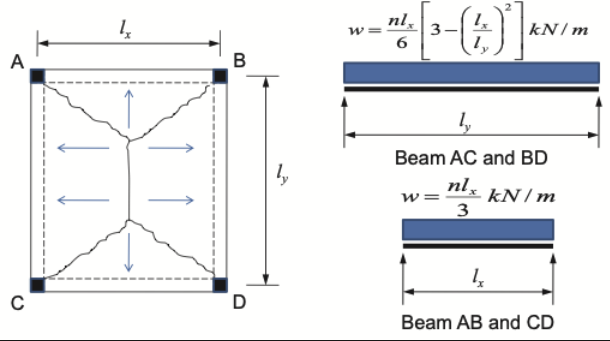


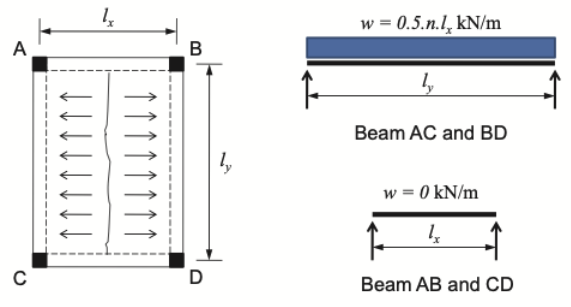

In [ ]:
# Seismic action load per square meter
Fph_ceiling = Fph / ceiling_area


# Define the horizontal_action_load dictionary
horizontal_action_load = [
    {
        "top_cross_rail": (Fph_ceiling * top_cross_rail_length * mm / 6) * (3 - (furring_channel_length / top_cross_rail_length) ** 2),
        "furring_channel": (Fph_ceiling * furring_channel_length * mm / 3)
    },
    {
        "top_cross_rail": 0.5 * (Fph_ceiling) / ceiling_area * top_cross_rail_length * mm,
        "furring_channel": 0.0
    }
]

# Determine the index based on the ratio
index = int(ceiling_aspect_ratio >= 2)

# Get the selected load
horizontal_action_load = horizontal_action_load[index]

# Get the selected load
long_dir_horizontal_action = horizontal_action_load["top_cross_rail"] * top_cross_rail_length * mm * 0.6

# Get the selected load
short_dir_horizontal_action = horizontal_action_load["furring_channel"] * furring_channel_length * mm * 0.6

#check axial load in furring channel
Fa_lining_long_dir = {"Check lining capacity under seismic action":
                         AS_NZS_1170_0_2002.uls_strength(lining_capacity, long_dir_horizontal_action)}
#check axial load in furring channel
Fa_lining_short_dir = {"Check lining capacity under seismic action":
                         AS_NZS_1170_0_2002.uls_strength(lining_capacity, short_dir_horizontal_action)}


### Braced design

In [ ]:
# Engineering Evaluation seismic_restraint = braced
# Seismic design capacity for a braced ceiling will always be greater than or equal to the design action.
# The design action is divided by the brace capacity to give the number of braces that are required for a particular ceiling configuration.
# To ensure stability under load (no twisting), the minumum number of braces is 2 per ceiling.
ceiling_mass_sqm = seismic_part_weight / ceiling_area
plenum_mm = floor_height - ceiling_height
if plenum_mm > 3000:
    plenum_mm = 2999
brace_capacity = gridlok_capacity

if brace_type == "Tracklok":

    # assign brace capacity
    brace_capacity = brace_stud_capacity
else:
    pass

brace_capacity_n = brace_capacity * g
brace_capacity_n = min(brace_capacity_n, brace_anchor_capacity)
max_area_per_brace = brace_capacity_n / (response_coefficient * ceiling_mass_sqm)
side_area_per_brace = np.sqrt(max_area_per_brace)
if ceiling_area > max_area_per_brace:
    required_number_braces = np.ceil(ceiling_area / max_area_per_brace)
    if required_number_braces % 2 != 0:
        required_number_braces += 1
    if required_number_braces < 2:
        required_number_braces = 2
else:
    if max_area_per_brace < (top_cross_rail_spacing * furring_channel_spacing):
        required_number_braces = 1
    else:
        pass

In [ ]:
total_brace_capacity = brace_capacity_n * required_number_braces


perimeter_gap_x = np.round(plenum_mm * 0.025)
if perimeter_gap_x < 20:
    perimeter_gap_x = 20


ULS_wall_load_x = 0

brace_check = {"Check brace capcity":
                           AS_NZS_1170_0_2002.uls_strength(total_brace_capacity, Fph)}

## Gravity and Wind Combinations - Load path component design check: 1.2 G + 1.0 W

In [ ]:
Ed_permanent_and_wind_action_a = [1.2, 1.0]
Wa_w = Ed_permanent_and_wind_action_a[0] * Gc + Ed_permanent_and_wind_action_a[1] * wind_load

## Gravity and Wind Combinations - Load path component design check: 0.9 G - 1.0 W

In [ ]:
Ed_permanent_and_wind_action_b = [0.9, 1.0]
Wb_w = Ed_permanent_and_wind_action_b[0] * Gc - Ed_permanent_and_wind_action_b[1] * wind_load

## Gravity and Wind Combinations - Load path component design check

In [ ]:
#strength check for 4.2.2.d and 4.2.2.e is same load path, check critical load combination only
W = max(Wa_w,Wb_w)

### Top Cross Rail

In [ ]:
#check bending in top cross rail

#weight per top cross rail
W_top_cross_rail = W / (furring_channel_length / top_cross_rail_spacing)

#weight per m on top cross rail
w_top_cross_rail_m = W_top_cross_rail / (top_cross_rail_length * mm)

#top cross rail bending moment between hangers
# M = wL^2 / 10

Ma =  w_top_cross_rail_m * (hanger_spacing * mm)**2 / 10 * N * m

#check top cross rail bending, bottom fibre
Mbx_wind_top_cross_rail_check = {"Check bending in top cross rail under wind":
                       AS_NZS_1170_0_2002.uls_strength(Mbx_top_cross_rail, Ma)}

### Furring Channel

In [ ]:
#check bending in furring channel

#weight per furring channel
W_furring_channel = W / (top_cross_rail_length / furring_channel_spacing)

#weight per m on furring channel
w_furring_channel_m = W_furring_channel / (furring_channel_length * mm)

#furring channel bending moment between hangers
# M = wL^2 / 10
Ma =  w_furring_channel_m * (top_cross_rail_spacing * mm)**2 / 10 * N * m

#check furring channel bending, bottom fibre
Mbx_wind_furring_channel_check = {"Check bending in furring channel under wind":
                        AS_NZS_1170_0_2002.uls_strength(Mbx_furring_channel, Ma)}

### Wall Angle

In [ ]:
#check shear in wall angle

#weight per wall angle connection, for continuous beam with pinned end connection
V_wall_angle = 0.6 * w_top_cross_rail_m * hanger_spacing * mm

V_wind_wall_angle_check = {"Check shear in wall angle under gravity":
                      AS_NZS_1170_0_2002.uls_strength(shear_wall_angle_capacity, V_wall_angle)}

### Compression Stud

In [ ]:
area_stud = compression_stud_capacity / (W / ceiling_area)
number_compression_stud = ceiling_area / area_stud
total_stud_capacity = number_compression_stud * compression_stud_capacity
stud_check_wind = {"Check stud capcity":
                           AS_NZS_1170_0_2002.uls_strength(total_stud_capacity, Fph)}

## SLS Performance under Gravity and Imposed Loads - 1.0 G 1.0 Q

In [ ]:
Ed_sls = [1.0, 1.0]
W = Ed_sls[0] * Gc + Ed_sls[1] * Q

## Deflection criteria Table C1- 1170.0: 2002
deflection_criteria = (hanger_spacing / 360) * mm

## SLS Gravity and Imposed Combinations - Load path component design check

In [ ]:
#check deflection in top cross rail and furring channel

#weight per top cross rail
W_top_cross_rail = W / (furring_channel_length / top_cross_rail_spacing) * N

#weight per m on top cross rail
w_top_cross_rail = W_top_cross_rail / (top_cross_rail_length * mm) * N / m

#weight per furring channel perpendicular
W_furring_channel_perpendicular = W / (top_cross_rail_length / furring_channel_spacing) * N

#weight per m on furring channel perpendicular
w_furring_channel_perpendicular = W_furring_channel / (furring_channel_length * mm) * N / m

#weight per furring channel horizontal grid types B and D
W_furring_channel_parallel = W / (furring_channel_length / (top_cross_rail_spacing/2)) * N

#weight per m on furring channel horizontal grid types B and D
w_furring_channel_parallel = W_furring_channel / (top_cross_rail_length * mm) * N / m

deflection = ((0.0065 * w_top_cross_rail * (hanger_spacing * mm)**4 /  E * (MPa) * Ix_top_cross_rail * (mm**4)) +
          (5 * w_furring_channel_perpendicular * ((top_cross_rail_spacing * mm) ** 4) / (384 * E * (MPa) * Ix_furring_channel * (mm**4))))

deflection_check = {
    "Check deflection":AS_NZS_1170_0_2002.sls(deflection, deflection_criteria)
}

In [ ]:
## Envelope check across components

### Lining Checks
lining_checks = [
    Fa_lining_long_dir,
    Fa_lining_short_dir
]

critical_lining = max(lining_checks, key=lambda check: list(check.values())[0][1])

### Top Cross Rail Checks
top_cross_rail_checks = [
    Mbx_gravity_top_cross_rail_check,
    Mbx_wind_top_cross_rail_check,
]
### top cross rail gravity Checks
top_cross_rail_gravity = [
    Mbx_gravity_top_cross_rail_check,
]
critical_top_cross_rail_gravity = max(top_cross_rail_gravity, key=lambda check: list(check.values())[0][1])
critical_top_cross_rail = max(top_cross_rail_checks, key=lambda check: list(check.values())[0][1])
max_tee_length_top_cross_rail = top_cross_rail_length * 0.99 / list(critical_top_cross_rail.values())[0][1]

### furring channel Checks
furring_channel_checks = [
    Mbx_gravity_furring_channel_check,
    Mbx_wind_furring_channel_check
]
### furring channel gravity Checks
furring_channel_gravity = [
    Mbx_gravity_furring_channel_check,
]
critical_furring_channel_gravity = max(furring_channel_gravity, key=lambda check: list(check.values())[0][1])
critical_furring_channel = max(furring_channel_checks, key=lambda check: list(check.values())[0][1])
max_tee_length_furring_channel = furring_channel_length * 0.99 / list(critical_furring_channel.values())[0][1]

### Wall Angle Checks
wall_angle_checks = [
    V_wall_angle_check,
]
critical_wall_angle = max(wall_angle_checks, key=lambda check: list(check.values())[0][1])

### Hanger Checks
hanger_checks = [
    T_hanger_check
]
critical_hanger = max(hanger_checks, key=lambda check: list(check.values())[0][1])

### Compression Stud Checks
stud_checks = [
    stud_check_wind
]
critical_stud = max(stud_checks, key=lambda check: list(check.values())[0][1])

### Brace Checks
brace_checks_subtype_based = {
    True: [brace_check],
    False: [],
}
brace_checks = brace_checks_subtype_based[braced_subtype]

critical_brace = (
    max(brace_checks, key=lambda check: list(check.values())[0][1])
    if brace_checks
    else {"No brace checks required": (None, 0.0)}
)
### Deflection Checks
deflection_checks = [deflection_check]
critical_deflection = max(deflection_checks, key=lambda check: list(check.values())[0][1])

### Envelope Checks
critical_component = [
    critical_top_cross_rail_gravity,
    critical_furring_channel_gravity,
    critical_brace,
    critical_deflection,
    critical_hanger,
    critical_stud,
]
critical_component = max(critical_component, key=lambda check: list(check.values())[0][1])

## Optimisation Calculations

In [ ]:
#optimisation parameter - maximum top cross rail length

# Define the deflection calculation as functions that take hanger_spacing as an input
deflection_calculation = (lambda hanger_spacing: (0.0065 * w_top_cross_rail * (hanger_spacing * mm)**4 / (E * MPa * Ix_top_cross_rail * (mm**4))) +
                                 (5 * w_furring_channel_perpendicular * ((top_cross_rail_spacing * mm)**4) / (384 * E * MPa * Ix_furring_channel * (mm**4))))


# Function to calculate max deflection with an iterative approach
def find_max_hanger_spacing(
    deflection_criteria,
    min_spacing=600,
    max_spacing=5000,
    tolerance=0.01,
    max_iterations=100,
):
    low = min_spacing
    high = max_spacing

    for _ in range(max_iterations):
        mid = (low + high) / 2
        current_deflection = deflection_calculation(mid)
        deflection_ratio = current_deflection / deflection_criteria

        if abs(deflection_ratio - 1.0) <= tolerance:
            return np.floor(mid / 10) * 10

        if deflection_ratio > 1.0:
            high = mid
        else:
            low = mid

    # If we exit the loop, return the closest value
    final_deflection_low = deflection_calculation(low)
    final_deflection_high = deflection_calculation(high)

    if abs(final_deflection_low / deflection_criteria - 1.0) < abs(
        final_deflection_high / deflection_criteria - 1.0
    ):
        return low
    else:
        return high

max_hanger_spacing_T_hanger = hanger_spacing / T_hanger_check['Check tension in hanger under gravity'][1]
max_hanger_spacing_deflection = find_max_hanger_spacing(deflection_check['Check deflection'][1], deflection_criteria, hanger_spacing)

max_hanger_spacing = min(max_hanger_spacing_T_hanger, max_hanger_spacing_deflection)
print("max_hanger_spacing_deflection: ",max_hanger_spacing_deflection)


max_hanger_spacing_deflection:  1200


# Results

In [ ]:
# First DataFrame
df_part1 = pd.DataFrame({
    "location": [location],
    "ceiling_top_cross_rail": [top_cross_rail_length],
    "ceiling_furring_channel": [furring_channel_length],
    # "Wp": [Wp],
})

# Create individual DataFrames for each component
lining_df = pd.DataFrame([
    {'Component': 'lining', 'Check Name': list(d.keys())[0], 'Status': 'Pass' if list(d.values())[0][1] <= 1 else 'Fail', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in lining_checks
])

top_cross_rail_df = pd.DataFrame([
    {'Component': 'top cross rail', 'Check Name': list(d.keys())[0], 'Status': 'Pass' if list(d.values())[0][1] <= 1 else 'Fail', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in top_cross_rail_checks
])

furring_channel_df = pd.DataFrame([
    {'Component': 'furring channel', 'Check Name': list(d.keys())[0], 'Status': 'Pass' if list(d.values())[0][1] <= 1 else 'Fail', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in furring_channel_checks
])

wall_angle_df = pd.DataFrame([
    {'Component': 'Wall Angle', 'Check Name': list(d.keys())[0], 'Status': 'Pass' if list(d.values())[0][1] <= 1 else 'Fail', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in wall_angle_checks
])

hanger_df = pd.DataFrame([
    {'Component': 'Hanger', 'Check Name': list(d.keys())[0], 'Status': 'Pass' if list(d.values())[0][1] <= 1 else 'Fail', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in hanger_checks
])

stud_df = pd.DataFrame([
    {'Component': 'Stud', 'Check Name': list(d.keys())[0], 'Status': 'Pass' if list(d.values())[0][1] <= 1 else 'Fail', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in stud_checks
])

brace_df = pd.DataFrame([
    {'Component': 'Brace', 'Check Name': list(d.keys())[0], 'Status': 'Pass', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in brace_checks
])

deflection_df = pd.DataFrame([
    {'Component': 'Deflection', 'Check Name': list(d.keys())[0], 'Status': 'Pass', 'Unity Value': round(list(d.values())[0][1], 3)}
    for d in deflection_checks
])

# Combine all DataFrames
df_part2 = pd.concat([lining_df, top_cross_rail_df, furring_channel_df, wall_angle_df, hanger_df, stud_df, brace_df, deflection_df], ignore_index=True)

# Third DataFrame
df_part3 = pd.DataFrame({
    "lining checks": {f"{list(critical_lining.keys())[0]}": np.round(list(critical_lining.values())[0][1], 2)},
    "top cross rail checks": {f"{list(critical_top_cross_rail.keys())[0]}": np.round(list(critical_top_cross_rail.values())[0][1], 2)},
    "furring channel checks": {f"{list(critical_furring_channel.keys())[0]}": np.round(list(critical_furring_channel.values())[0][1], 2)},
    "wall angle checks": {f"{list(critical_wall_angle.keys())[0]}": np.round(list(critical_wall_angle.values())[0][1], 2)},
    "hanger checks": {f"{list(critical_hanger.keys())[0]}": np.round(list(critical_hanger.values())[0][1], 2)},
    "brace checks": {f"{list(critical_brace.keys())[0]}": np.round(list(critical_brace.values())[0][1], 2)},
    "deflection check": {f"{list(critical_deflection.keys())[0]}": np.round(list(critical_deflection.values())[0][1], 2)},
    "critical component": {f"{list(critical_component.keys())[0]}": np.round(list(critical_component.values())[0][1], 2)}, #critical_component.keys(),
})

# Fourth DataFrame
df_part4 = pd.DataFrame({
    "Max hanger_spacing": [max_hanger_spacing],
    "compliance": [
        "Fail" if list(critical_component.values())[0][0] == False else "Pass"
    ],
})

In [ ]:
df_part1

,location,ceiling_top_cross_rail,ceiling_furring_channel
0,Auckland,10000,10000


In [ ]:
df_part2

,Component,Check Name,Status,Unity Value
0,lining,Check lining capacity under seismic action,Pass,0.288
1,lining,Check lining capacity under seismic action,Pass,0.288
2,top cross rail,Check bending in top cross rail under gravity,Pass,0.001
3,top cross rail,Check bending in top cross rail under wind,Pass,0.004
4,furring channel,Check bending in furring channel under gravity,Pass,0.001
5,furring channel,Check bending in furring channel under wind,Pass,0.004
6,Wall Angle,Check shear in wall angle under gravity,Pass,0.044
7,Hanger,Check tension in hanger under gravity,Pass,0.046
8,Stud,Check stud capcity,Pass,0.027
9,Brace,Check brace capcity,Pass,0.441


In [ ]:
df_part3

,lining checks,top cross rail checks,furring channel checks,wall angle checks,hanger checks,brace checks,deflection check,critical component
Check lining capacity under seismic action,0.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Check bending in top cross rail under wind,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
Check bending in furring channel under wind,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
Check shear in wall angle under gravity,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN
Check tension in hanger under gravity,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN
Check brace capcity,NaN,NaN,NaN,NaN,NaN,0.44,NaN,NaN
Check deflection,NaN,NaN,NaN,NaN,NaN,NaN,2.58,2.58


In [ ]:
df_part4

,Max hanger_spacing,compliance
0,1200,Fail
